In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/cleaned_data.csv")

print(df.head())

     price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  9100000  6000         4          1        2      yes        no      yes   
1  9100000  6600         4          2        2      yes       yes      yes   
2  8890000  4600         3          2        2      yes       yes       no   
3  8855000  6420         3          2        2      yes        no       no   
4  8750000  4320         3          1        2      yes        no      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no              no        2       no   semi-furnished  
1              no             yes        1      yes      unfurnished  
2              no             yes        2       no        furnished  
3              no             yes        1      yes   semi-furnished  
4             yes              no        2       no   semi-furnished  


In [ ]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
target = 'price'

In [ ]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("----------")

print("Linear Regression:")
evaluate(y_test, y_pred_lr)

print("Random Forest:")
evaluate(y_test, y_pred_rf)

Linear Regression:
MAE: 757676.2047449187
MSE: 1012526239040.6401
R2 Score: 0.611100599145767
----------
Random Forest:
MAE: 786927.2168458782
MSE: 1110721265563.6921
R2 Score: 0.5733850461958867
----------


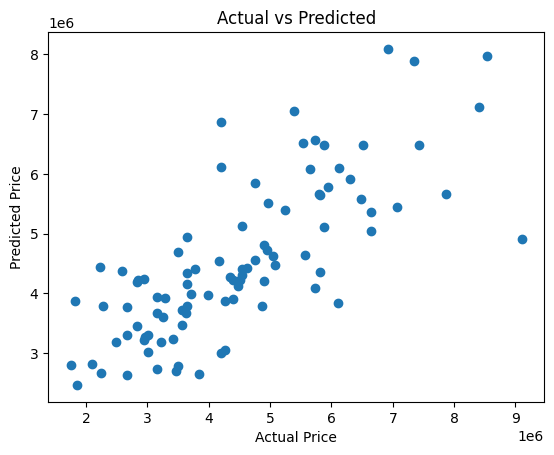

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [ ]:
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# The NameError 'loaded_model' is not defined likely occurred because the cell
# where 'loaded_model' is defined (cell 17af6190) was not run before this cell,
# or the kernel was restarted. Please ensure all preceding cells are run.

# However, even if 'loaded_model' was defined, this code would still produce an error.
# The 'loaded_model' is a RandomForestRegressor, which is a regression model.
# Regression models predict continuous values and do not have a 'predict_proba' method,
# which is used for classification models to output class probabilities.
# The 'roc_curve' function is also a metric specifically designed for binary classification tasks,
# not for regression.

# Therefore, this code is conceptually incorrect for evaluating a regression model.
# The lines attempting to calculate and plot an ROC curve have been commented out.

# y_prob = loaded_model.predict_proba(X_test)[:,1]
# fpr, tpr, _ = roc_curve(y_test, y_prob)

# plt.plot(fpr, tpr)
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.show()